In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

In [19]:
# processed filepaths

train_bkg = h5py.File('/global/cfs/cdirs/m3246/mbenyas/OmniLearned_distillation/LHCO/nsig_500/lhco_ad/train/bkg.h5')
train_data = h5py.File('/global/cfs/cdirs/m3246/mbenyas/OmniLearned_distillation/LHCO/nsig_500/lhco_ad/train/data.h5')

In [ ]:
def plot_features(h5file):

    # Particle Level Features

    # flattens all delta_eta values into single 1D array, for all N events, and all 2P particles/event
    delta_eta_values = h5file['data'][:, :, 0].ravel()
    delta_phi_values = h5file['data'][:, :, 1].ravel()
    log_pt_values = h5file['data'][:, :, 2].ravel()
    log_e_values = h5file['data'][:, :, 3].ravel()

    delta_eta_values_nonzero = delta_eta_values[log_pt_values != 0.0]
    delta_phi_values_nonzero = delta_phi_values[log_pt_values != 0.0]
    log_pt_values_nonzero = log_pt_values[log_pt_values != 0.0]
    log_e_values_nonzero = log_e_values[log_pt_values != 0.0]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    plots = [
        (delta_eta_values_nonzero, r'$\Delta\eta$'),
        (delta_phi_values_nonzero, r'$\Delta\phi$'),
        (log_pt_values_nonzero, r'$\log(p_T)$'),
        (log_e_values_nonzero, r'$\log(E)$'),
    ]

    for ax, (values, xlabel) in zip(axes.flat, plots):
        ax.hist(values, bins=100, histtype='step', linewidth=1.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()



    # Jet Level Features

    mjj_values = h5file['global'][:, 0]
    jet0_log_pt_values = h5file['global'][:, 1]
    jet0_pt_values = np.array([np.exp(elem) for elem in jet0_log_pt_values])
    jet0_eta_values = h5file['global'][:, 2]
    jet0_phi_values = h5file['global'][:, 3]
    jet0_log_mass_values = h5file['global'][:, 4]
    jet0_multiplicity_values = np.array([elem * 100 for elem in list(h5file['global'][:, 5])])
    jet1_log_pt_values = h5file['global'][:, 6]
    jet1_pt_values = np.array([np.exp(elem) for elem in jet1_log_pt_values])
    jet1_eta_values = h5file['global'][:, 7]
    jet1_phi_values = h5file['global'][:, 8]
    jet1_log_mass_values = h5file['global'][:, 9]
    jet1_multiplicity_values = np.array([elem * 100 for elem in list(h5file['global'][:, 10])])

    plt.figure()
    plt.hist(mjj_values, bins=100, histtype='step', linewidth=1.5)
    plt.xlabel('mjj')
    plt.ylabel('Count')
    plt.show()

    fig, axes = plt.subplots(2, 5, figsize=(16, 6))

    plots = [
        (jet0_pt_values, r'Jet 0 $p_T$'),
        (jet0_eta_values, r'Jet 0 $\eta$'),
        (jet0_phi_values, r'Jet 0 $\phi$'),
        (jet0_log_mass_values, r'Jet 0 $\log(m)$'),
        (jet0_multiplicity_values, r'Jet 0 Multiplicity'),
        (jet1_pt_values, r'Jet 1 $p_T$'),
        (jet1_eta_values, r'Jet 1 $\eta$'),
        (jet1_phi_values, r'Jet 1 $\phi$'),
        (jet1_log_mass_values, r'Jet 1 $\log(m)$'),
        (jet1_multiplicity_values, r'Jet 1 Multiplicity'),
    ]

    for ax, (values, xlabel) in zip(axes.flat, plots):
        ax.hist(values, bins=25, histtype='step', linewidth=1.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()




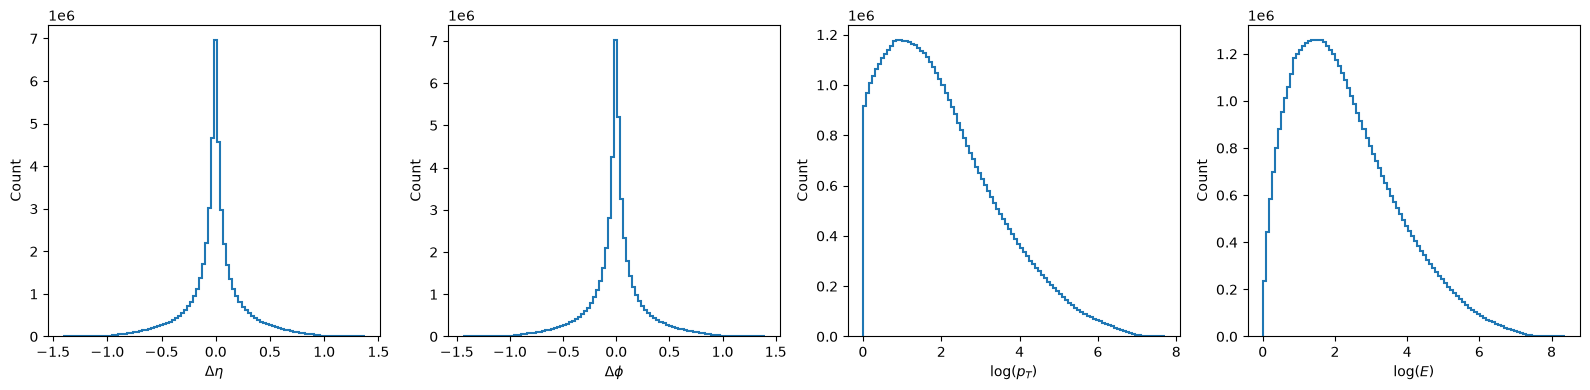

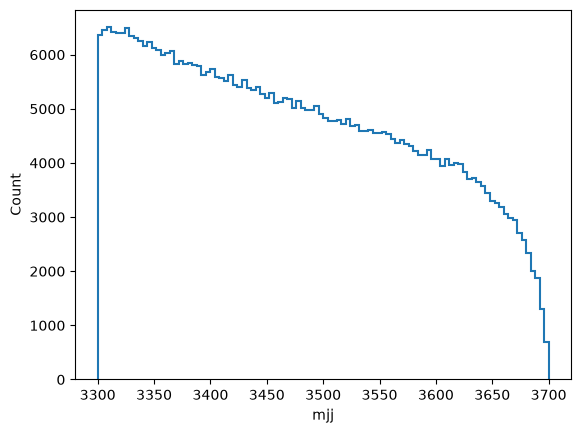

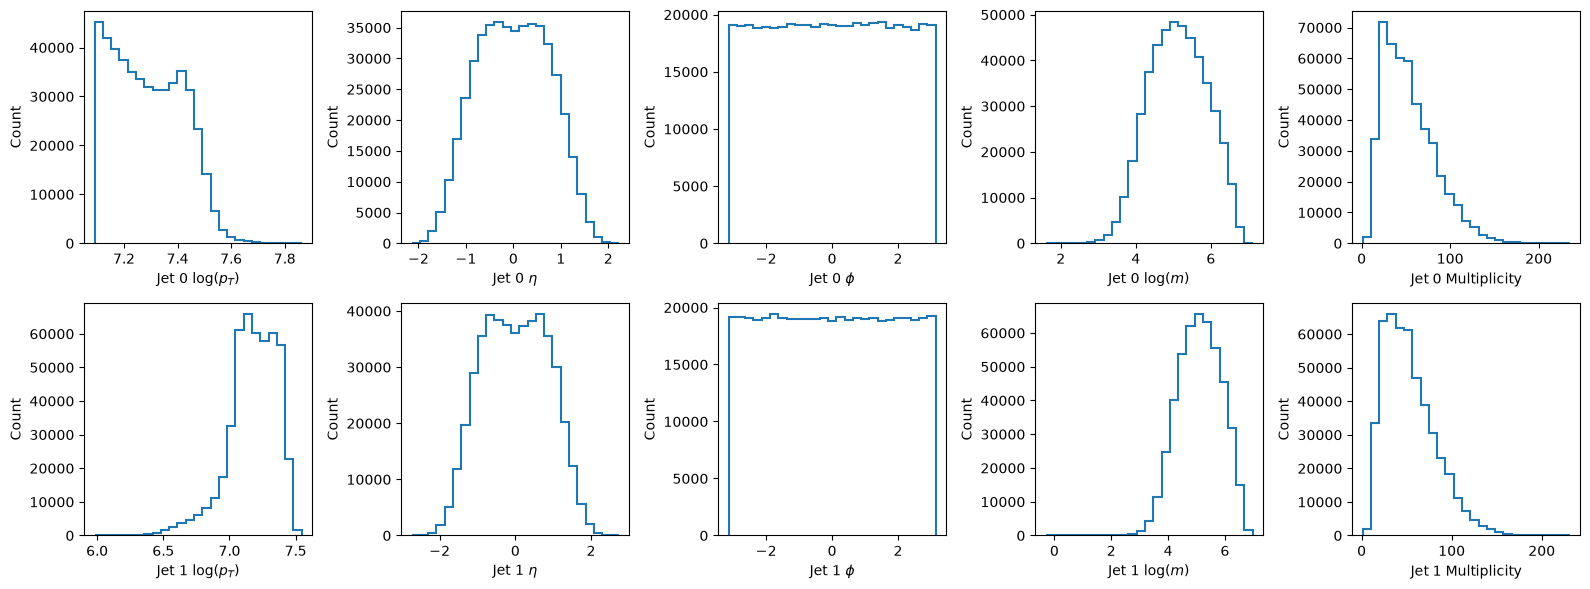

In [27]:
plot_features(train_bkg)

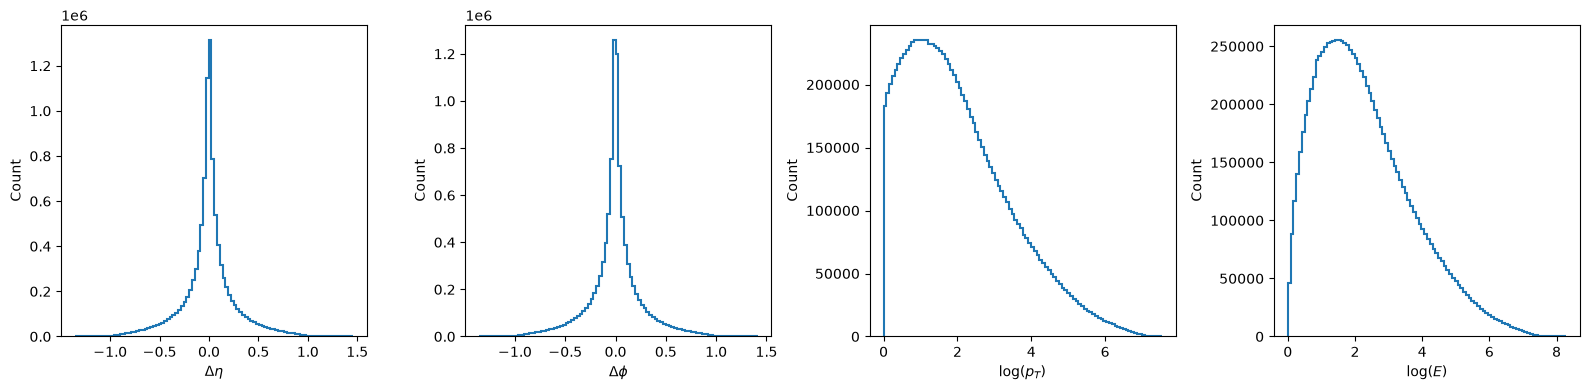

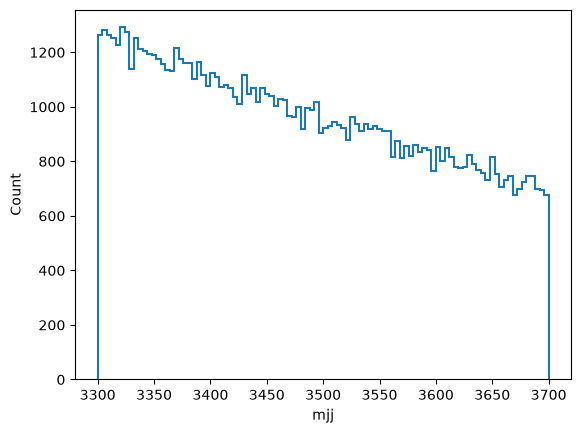

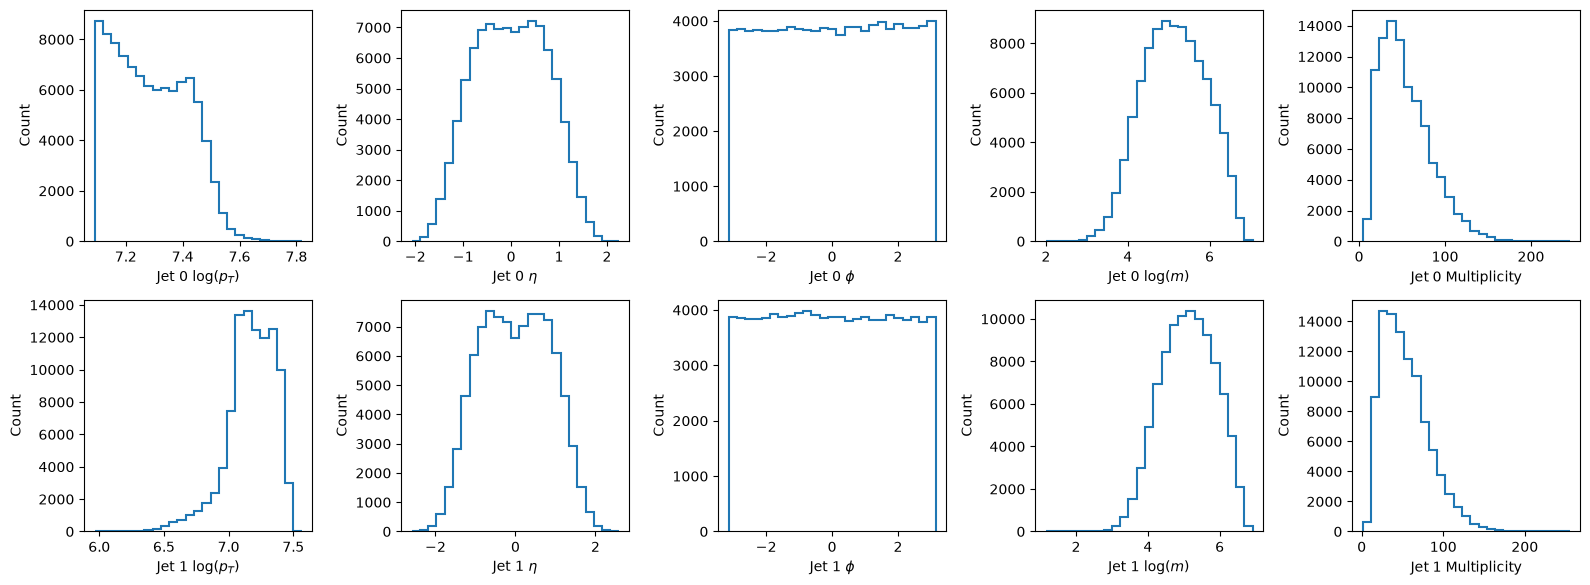

In [28]:
plot_features(train_data)

In [ ]:
train_bkg_extended_Vini = h5py.File('/global/cfs/cdirs/m3246/mbenyas/OmniLearn/LHCO/train_background_SR_extended.h5')

In [ ]:
# compare to Vini's original processed files

orig_jet0_pt_values = train_bkg_extended_Vini['jet'][:, 0, 0]
processed_jet0_pt_values = np.array([np.exp(elem) for elem in train_bkg['global'][:, 1]])
orig_jet1_pt_values = train_bkg_extended_Vini['jet'][:, 1, 0]
processed_jet1_pt_values = np.array([np.exp(elem) for elem in train_bkg['global'][:, 6]])

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

plots = [
    (orig_jet0_pt_values, r'Jet 0 $p_T$ from train_background_SR_extended'),
    (processed_jet0_pt_values, r' Processed Jet 0 $p_T$'),
    (orig_jet1_pt_values, r'Jet 1 $p_T$ from train_background_SR_extended'),
    (processed_jet1_pt_values, r' Processed Jet 1 $p_T$'),
]

for ax, (values, xlabel) in zip(axes.flat, plots):
    ax.hist(values, bins=25, histtype='step', linewidth=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## Source vs processed comparison

Systematic check of every feature in `LHCO/nsig_*/lhco_ad/` against the
`{train,val}_{background,signal}_{SR,SR_extended}.h5` files it was built from.

Layouts (per `convert_lhco.py`):

| | source | processed |
|---|---|---|
| particles | `data` (N, 2, P, 7) = deta, dphi, log(1-pt_rel), **log_pt**, log(1-E_rel), **log_e**, dR | `data` (N, 2P, 6) = deta, dphi, log_pt, log_e, onehot_j0, onehot_j1 |
| jets | `jet` (N, 2, 5) = pt, eta, phi, mass, multiplicity | `global` (N, 11) = mjj, then per jet (log_pt, eta, phi, log_mass, mult/100) |
| mjj | `pid` (N,) | `global[:, 0]` |

The two intended differences: constituents with log_pt <= 0 are zeroed, and the
two jets are merged into one row with a one-hot tag. Everything else should match.

In [2]:
from pathlib import Path

SRC = Path('/global/cfs/cdirs/m3246/mbenyas/OmniLearn/LHCO')
PROC = Path('/global/cfs/cdirs/m3246/mbenyas/OmniLearned_distillation/LHCO')

SRC_PART = {'delta_eta': 0, 'delta_phi': 1, 'log_pt': 3, 'log_e': 5}  # name -> source column
PART_FEATS = list(SRC_PART)                                          # same order in processed cols 0-3
JET_FEATS = ['pt', 'eta', 'phi', 'mass', 'mult']

# which source files each processed pool was built from
SOURCE_POOLS = {
    'bkg':  ['train_background_SR_extended', 'val_background_SR_extended'],
    'data': ['train_background_SR', 'val_background_SR'],  # + nsig injected signal events
}
SIGNAL_FILES = ['train_signal_SR', 'val_signal_SR']
UNUSED_FILES = ['train_background_SB', 'val_background_SB']  # not inputs to convert_lhco.py

In [3]:
def _block(f, keys, n, rng):
    """Contiguous n-event block from a random offset. The files are unordered
    (checked: no index correlation with mjj or jet pT), so this is unbiased and
    ~50x faster than scattered fancy indexing on these multi-GB datasets."""
    size = f[keys[0]].shape[0]
    n = min(n, size)
    s = int(rng.integers(0, size - n + 1))
    return [f[k][s:s + n] for k in keys]


def load_source(names, n=20000, seed=0):
    """n events pooled evenly over the named source files -> jet, part, mjj."""
    rng = np.random.default_rng(seed)
    blocks = []
    for name in names:
        with h5py.File(SRC / f'{name}.h5') as f:
            blocks.append(_block(f, ['jet', 'data', 'pid'], max(1, n // len(names)), rng))
    return [np.concatenate(x) for x in zip(*blocks)]


def load_processed(pool, nsig=500, n=20000, seed=0, splits=('train', 'val', 'test'), suffix=''):
    """n events pooled evenly over the processed splits -> global, part.

    `suffix` picks which LHCO/nsig_<N><suffix>/ folder to read: '_unstd' for
    the pre-standardization backup, '' (default) for the current
    standardized output."""
    rng = np.random.default_rng(seed)
    blocks = []
    for s in splits:
        with h5py.File(PROC / f'nsig_{nsig}{suffix}' / 'lhco_ad' / s / f'{pool}.h5') as f:
            blocks.append(_block(f, ['global', 'data'], max(1, n // len(splits)), rng))
    return [np.concatenate(x) for x in zip(*blocks)]

In [4]:
def src_feats(jet, part, mjj, pt_cut=True):
    """Source arrays -> flat feature dict in physical units. pt_cut applies
    convert_lhco.py's log_pt>0 cut so the particle sample matches the processed
    one; pt_cut=False keeps every non-padded constituent instead."""
    live = part[..., 3] > 0 if pt_cut else np.abs(part).sum(-1) > 0
    out = {f'part_{k}': part[..., c][live] for k, c in SRC_PART.items()}
    for j in range(2):
        for i, k in enumerate(JET_FEATS[:4]):
            out[f'jet{j}_{k}'] = jet[:, j, i]
        # source multiplicity counts non-padded constituents, so recount under the cut
        out[f'jet{j}_mult'] = live[:, j].sum(-1).astype(float) if pt_cut else jet[:, j, 4]
    out['mjj'] = mjj
    return out


def proc_feats(glob, part, raw=False):
    """Processed arrays -> the same feature dict. raw=False (default) undoes
    the log/scaling convert_lhco.py applied to `global`, matching source
    physical units. raw=True skips that undo and returns `global` columns
    as-is -- for the standardized output, where values are z-scores, not
    physical units, so exp()/*100 would be meaningless."""
    live = part[..., 2] > 0
    out = {f'part_{k}': part[..., i][live] for i, k in enumerate(PART_FEATS)}
    for j in range(2):
        c = 1 + 5 * j
        out[f'jet{j}_pt'] = glob[:, c] if raw else np.exp(glob[:, c])
        out[f'jet{j}_eta'] = glob[:, c + 1]
        out[f'jet{j}_phi'] = glob[:, c + 2]
        out[f'jet{j}_mass'] = glob[:, c + 3] if raw else np.exp(glob[:, c + 3])
        out[f'jet{j}_mult'] = glob[:, c + 4] if raw else glob[:, c + 4] * 100
    out['mjj'] = glob[:, 0]
    return out

In [26]:
def compare_hist(a, b, name, ax, bins=60, logy=False, labels=('source', 'processed'), c=None, c_label='processed_std'):
    """Overlay two (or three, if `c` is given) distributions on shared bins,
    area-normalised so unequal sample sizes still line up."""
    series = [a, b] + ([c] if c is not None else [])
    labs = list(labels) + ([c_label] if c is not None else [])
    lo, hi = np.percentile(np.concatenate(series), [0.1, 99.9])
    edges = np.linspace(lo, hi, bins + 1)
    for v, lab in zip(series, labs):
        ax.hist(v, bins=edges, histtype='step', density=True, linewidth=1.5, label=lab)
    ax.set_xlabel(name)
    if logy:
        ax.set_yscale('log')
    ax.legend(fontsize=7)


def compare_particles(sf, pf, pf_std, bins=60):
    """Overlay the 4 particle-level features convert_lhco.py keeps."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
    for ax, k in zip(axes, PART_FEATS):
        compare_hist(sf[f'part_{k}'], pf[f'part_{k}'], k, ax, bins, logy=True, c=pf_std[f'part_{k}'])
    fig.tight_layout()
    plt.show()


def compare_jets(sf, pf, pf_std, bins=40):
    """Overlay the 5 jet-level features, one row per jet."""
    fig, axes = plt.subplots(2, 5, figsize=(18, 6))
    for j in range(2):
        for ax, k in zip(axes[j], JET_FEATS):
            compare_hist(sf[f'jet{j}_{k}'], pf[f'jet{j}_{k}'], f'jet{j} {k}', ax, bins, c=pf_std[f'jet{j}_{k}'])
    fig.tight_layout()
    plt.show()


def compare_mjj(sf, pf, pf_std, bins=60):
    fig, ax = plt.subplots(figsize=(5, 3.5))
    compare_hist(sf['mjj'], pf['mjj'], 'mjj [GeV]', ax, bins, c=pf_std['mjj'])
    fig.tight_layout()
    plt.show()

In [27]:
def summary(sf, pf, zmax=5.0):
    """Per-feature counts/mean/std on both sides. `z` is the two-sample z-score
    of the mean difference, so it stays meaningful for features centred on zero
    (eta, phi); FLAG marks |z| > zmax, i.e. a gap too big to be subsampling noise."""
    hdr = (f"{'feature':16s}{'n_src':>10s}{'n_proc':>10s}{'mean_src':>12s}"
           f"{'mean_proc':>12s}{'std_src':>11s}{'std_proc':>11s}{'z':>8s}")
    print(hdr + '\n' + '-' * len(hdr))
    for k in sf:
        a, b = np.asarray(sf[k], float), np.asarray(pf[k], float)
        z = (a.mean() - b.mean()) / np.sqrt(a.var() / a.size + b.var() / b.size)
        print(f'{k:16s}{a.size:10d}{b.size:10d}{a.mean():12.4f}{b.mean():12.4f}'
              f"{a.std():11.4f}{b.std():11.4f}{z:8.2f}  {'FLAG' if abs(z) > zmax else ''}")


def pt_cut_effect(names, n=5000, seed=0):
    """Quantify the one intended particle-level difference: constituents dropped
    by convert_lhco.py's log_pt > 0 (pT > 1 GeV) cut."""
    _, part, _ = load_source(names, n, seed)
    pad, keep = np.abs(part).sum(-1) > 0, part[..., 3] > 0
    print(f'non-padded constituents : {pad.sum():,}')
    print(f'surviving log_pt > 0    : {keep.sum():,}  ({100 * keep.sum() / pad.sum():.2f}%)')
    print(f'mean jet multiplicity   : {pad.sum(-1).mean():.2f} -> {keep.sum(-1).mean():.2f}')


def check_structure(pool='bkg', nsig=500, n=2000, seed=0):
    """Verify the processed layout: the one-hot marks jet0 in the first P slots
    and jet1 in the last P, is set exactly on surviving particles, and `global`
    multiplicity equals that survivor count."""
    glob, part = load_processed(pool, nsig, n=n, seed=seed)
    P = part.shape[1] // 2
    live = part[..., 2] > 0
    print('jet0 one-hot confined to first half :', not part[:, P:, 4].any())
    print('jet1 one-hot confined to second half:', not part[:, :P, 5].any())
    print('one-hot set iff log_pt > 0          :', np.array_equal(live, part[..., 4:6].sum(-1) > 0))
    print('padding rows all zero               :', not part[~live].any())
    for j in range(2):
        n_live = live[:, j * P:(j + 1) * P].sum(-1)
        print(f'jet{j} global mult == survivor count :', np.allclose(glob[:, 5 * j + 5] * 100, n_live))


def compare_pool(pool='bkg', nsig=500, n=20000, seed=0, pt_cut=True):
    """Full source-vs-processed comparison for one pool: numeric table, then
    mjj, particle, and jet overlays, each showing source vs. the
    pre-standardization backup (unstd) vs. the current standardized output
    (plotted raw, un-inverted -- see proc_feats(raw=True))."""
    sf = src_feats(*load_source(SOURCE_POOLS[pool], n, seed), pt_cut=pt_cut)
    pf = proc_feats(*load_processed(pool, nsig, n=n, seed=seed, suffix='_unstd'))
    pf_std = proc_feats(*load_processed(pool, nsig, n=n, seed=seed), raw=True)
    summary(sf, pf)
    compare_mjj(sf, pf, pf_std)
    compare_particles(sf, pf, pf_std)
    compare_jets(sf, pf, pf_std)
    return sf, pf, pf_std

In [28]:
check_structure('bkg', nsig=500)
print()
pt_cut_effect(SOURCE_POOLS['bkg'])

jet0 one-hot confined to first half : True
jet1 one-hot confined to second half: True
one-hot set iff log_pt > 0          : True
padding rows all zero               : True
jet0 global mult == survivor count : False
jet1 global mult == survivor count : False

non-padded constituents : 575,453
surviving log_pt > 0    : 537,680  (93.44%)
mean jet multiplicity   : 57.55 -> 53.77


feature              n_src    n_proc    mean_src   mean_proc    std_src   std_proc       z
------------------------------------------------------------------------------------------
part_delta_eta    21472328  19901079      0.0004      0.0000     0.2546     0.2547    4.83  
part_delta_phi    21472328  19901079     -0.0002      0.0001     0.2515     0.2515   -4.53  
part_log_pt       21472328  19901079      2.0222      2.0228     1.4013     1.4019   -1.48  
part_log_e        21472328  19901079      2.2850      2.2852     1.4216     1.4223   -0.59  
jet0_pt             200000    185670   1477.0747   1476.8596   192.2840   192.0394    0.35  
jet0_eta            200000    185670     -0.0023     -0.0025     0.7490     0.7490    0.12  
jet0_phi            200000    185670      0.0062      0.0042     1.8118     1.8152    0.34  
jet0_mass           200000    185670    221.9305    221.1422   169.9906   169.7335    1.44  
jet0_mult           200000    185670     53.9640     53.7540    29.0234   

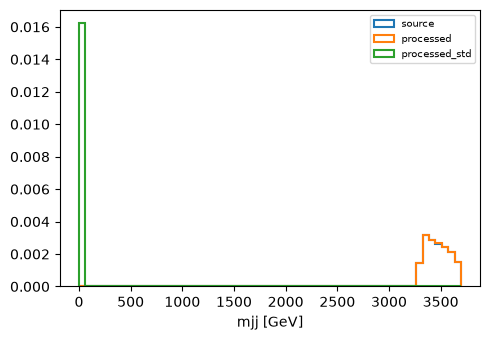

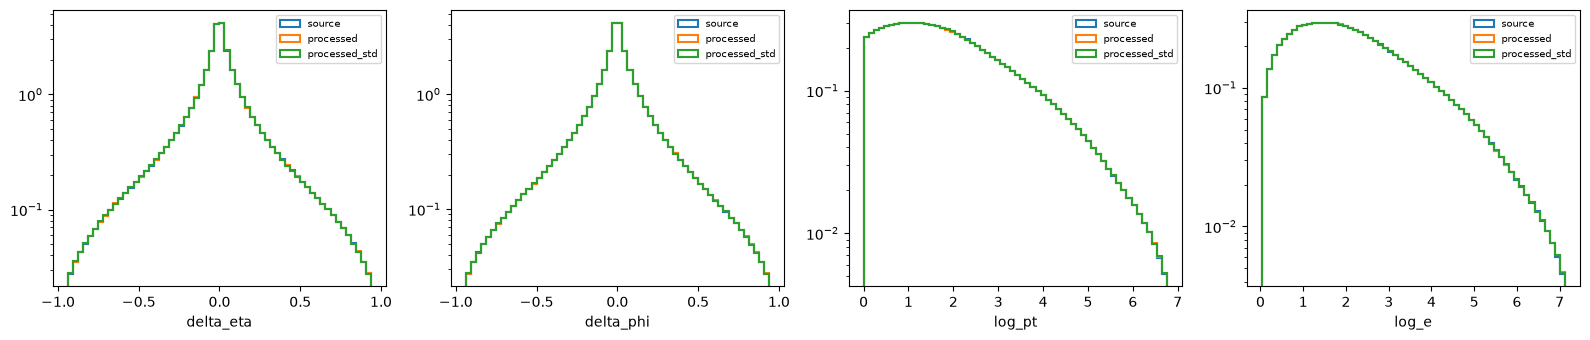

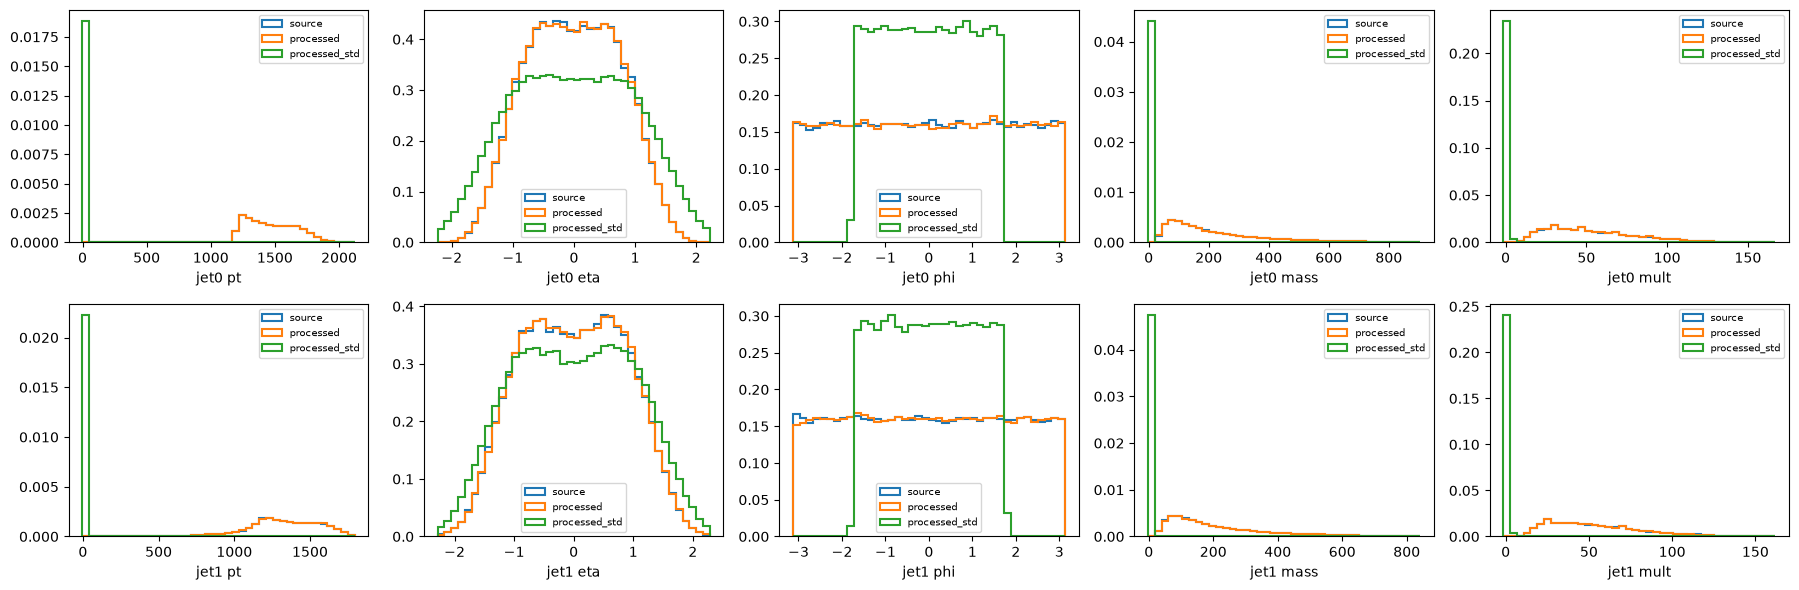

In [29]:
# bkg.h5 vs train/val_background_SR_extended.h5
sf_bkg, pf_bkg, pf_bkg_std = compare_pool('bkg', nsig=500, n=200000)

feature              n_src    n_proc    mean_src   mean_proc    std_src   std_proc       z
------------------------------------------------------------------------------------------
part_delta_eta    12995462   9811095     -0.0001     -0.0001     0.2569     0.2570    0.12  
part_delta_phi    12995462   9811095     -0.0002     -0.0000     0.2537     0.2538   -1.28  
part_log_pt       12995462   9811095      2.0172      2.0182     1.3979     1.3981   -1.65  
part_log_e        12995462   9811095      2.2848      2.2857     1.4186     1.4185   -1.37  
jet0_pt             120322     90830   1473.4933   1474.0818   191.9813   192.1884   -0.70  
jet0_eta            120322     90830      0.0015      0.0023     0.7558     0.7558   -0.24  
jet0_phi            120322     90830      0.0154      0.0166     1.8152     1.8149   -0.15  
jet0_mass           120322     90830    225.4384    226.0771   172.6239   172.9012   -0.84  
jet0_mult           120322     90830     54.2778     54.2628    29.2199   

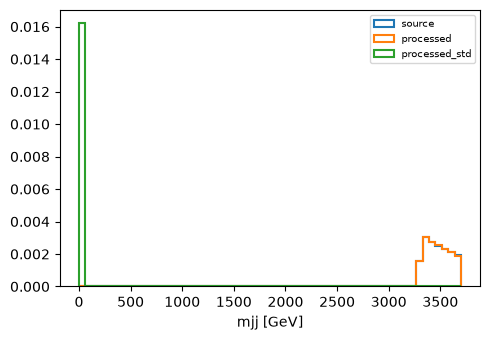

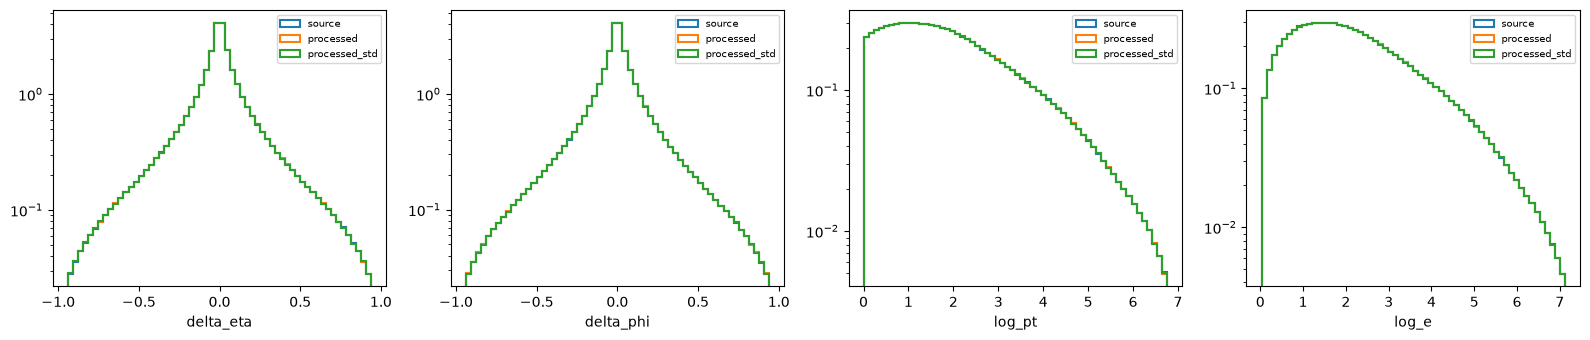

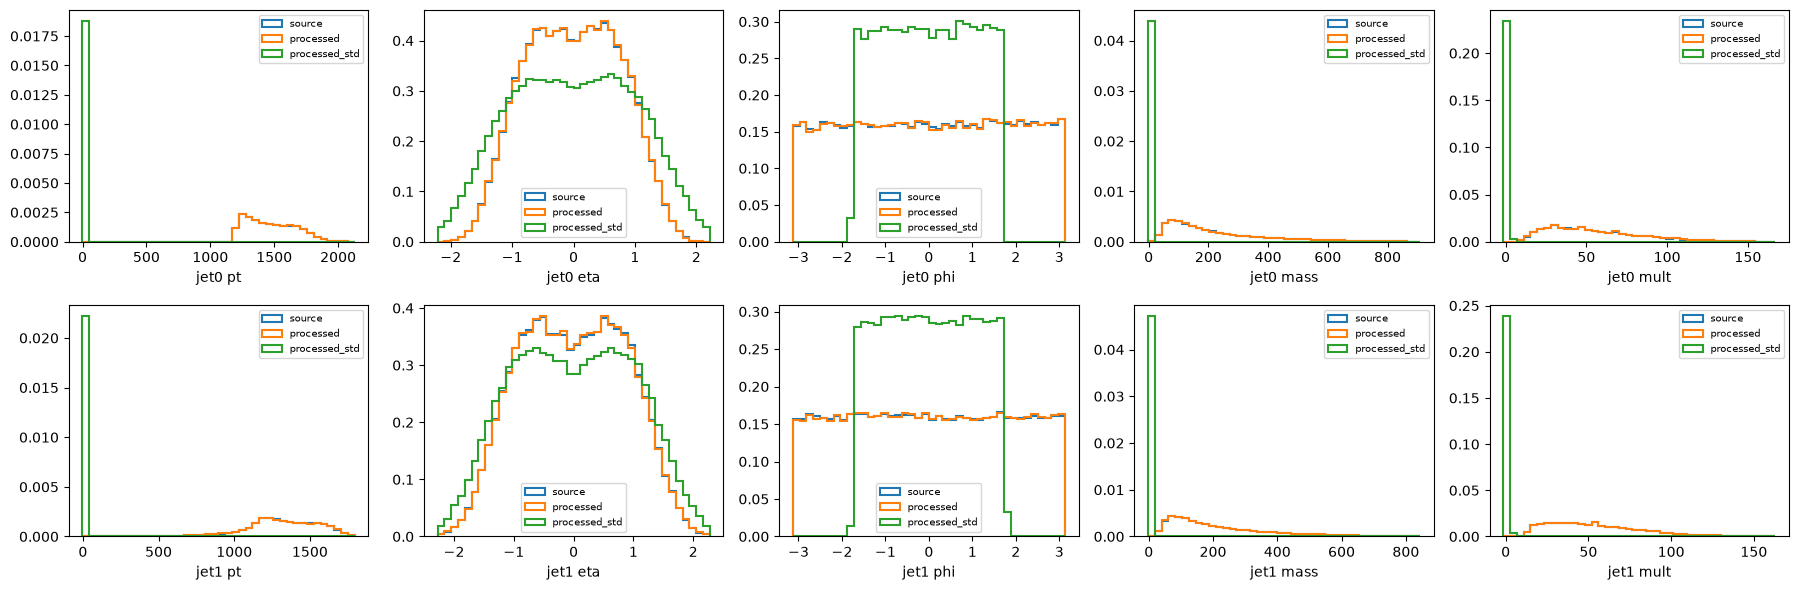

In [30]:
# data.h5 vs train/val_background_SR.h5 (the 500 injected signal events are 0.4% of the pool)
sf_data, pf_data, pf_data_std = compare_pool('data', nsig=500, n=200000)

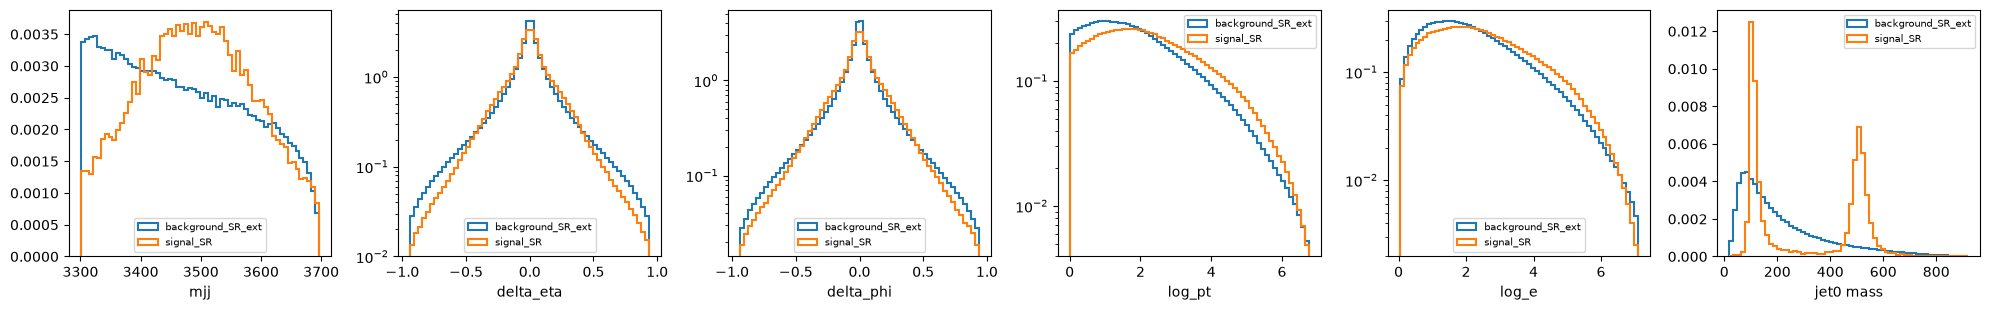

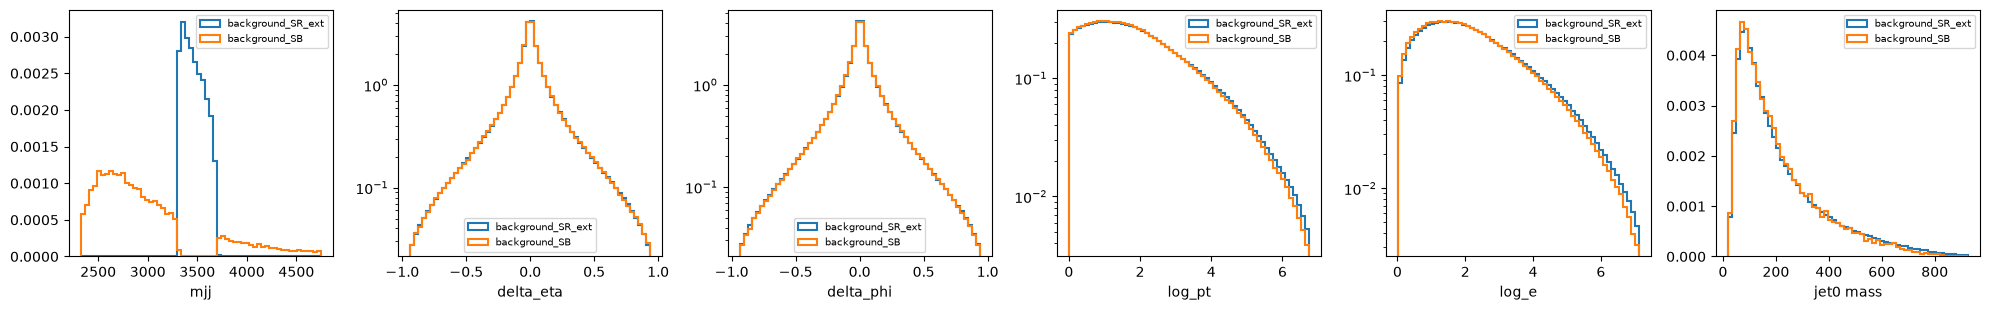

In [31]:
# signal vs background at source level, and the SB files convert_lhco.py never reads
sf_sig = src_feats(*load_source(SIGNAL_FILES, n=20000))
sf_sb = src_feats(*load_source(UNUSED_FILES, n=20000))

for other, lab in ((sf_sig, 'signal_SR'), (sf_sb, 'background_SB')):
    fig, axes = plt.subplots(1, 6, figsize=(20, 3.2))
    compare_hist(sf_bkg['mjj'], other['mjj'], 'mjj', axes[0], labels=('background_SR_ext', lab))
    for ax, k in zip(axes[1:], PART_FEATS):
        compare_hist(sf_bkg[f'part_{k}'], other[f'part_{k}'], k, ax, logy=True,
                     labels=('background_SR_ext', lab))
    compare_hist(sf_bkg['jet0_mass'], other['jet0_mass'], 'jet0 mass', axes[5],
                 labels=('background_SR_ext', lab))
    fig.tight_layout()
    plt.show()